In [ ]:
# ============================================================
# EXPERIMENT 3 - CNN FOR CIFAR-10 (PyTorch)
# Fast dataset loading via Hugging Face + PyTorch DataLoaders
# ============================================================

!pip -q install datasets scikit-learn


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

transform = transforms.ToTensor()


Device: cuda


In [ ]:
# ============================================================
# LOAD CIFAR-10
# No manual ZIP download is needed.
# Hugging Face downloads the dataset and caches it in Colab.
# ============================================================

hf_data = load_dataset("uoft-cs/cifar10")

class CIFAR10Torch(Dataset):
    def __init__(self, hf_split, transform=None):
        self.data = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]["img"]
        label = int(self.data[idx]["label"])
        if self.transform:
            image = self.transform(image)
        return image, label

train_set = CIFAR10Torch(hf_data["train"], transform)
test_set = CIFAR10Torch(hf_data["test"], transform)

print("Training images:", len(train_set))
print("Testing images :", len(test_set))


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Training images: 50000
Testing images : 10000


===== Dataset Dimensions =====
Training Images : 50000
Testing Images  : 10000
Image Shape     : torch.Size([3, 32, 32])
Pixel Range     : 0.13333334028720856 to 0.7960784435272217


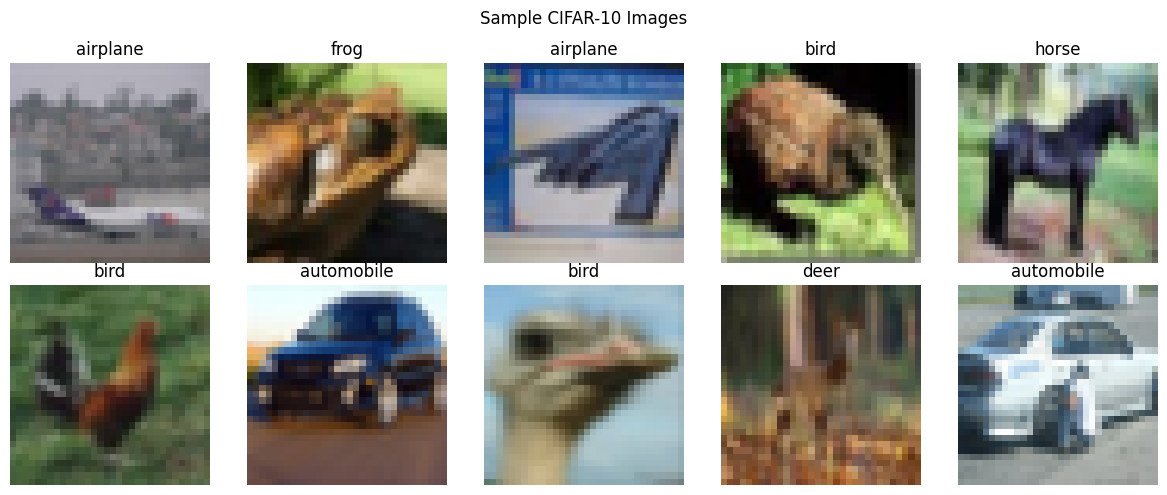

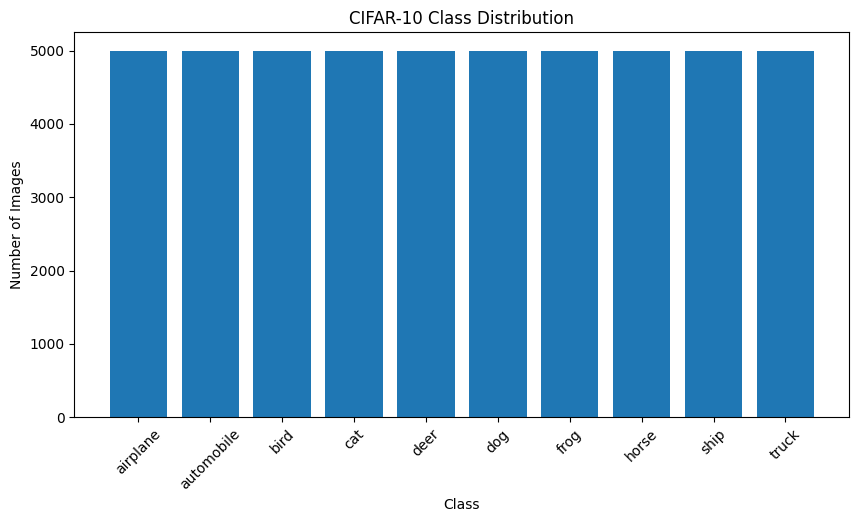


Images per class
airplane     : 5000
automobile   : 5000
bird         : 5000
cat          : 5000
deer         : 5000
dog          : 5000
frog         : 5000
horse        : 5000
ship         : 5000
truck        : 5000


In [ ]:
# ============================================================
# TASK 1 - Load CIFAR-10
# Display 10 sample images, dimensions, class distribution
# ============================================================

print("===== Dataset Dimensions =====")
print("Training Images :", len(train_set))
print("Testing Images  :", len(test_set))

image, label = train_set[0]
print("Image Shape     :", image.shape)  # PyTorch: C x H x W
print("Pixel Range     :", image.min().item(), "to", image.max().item())

# Display 10 sample images
plt.figure(figsize=(12, 5))
for i in range(10):
    img, lbl = train_set[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(CLASS_NAMES[lbl])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

# Class distribution
labels = np.array(hf_data["train"]["label"])
counts = np.bincount(labels, minlength=10)

plt.figure(figsize=(10, 5))
plt.bar(CLASS_NAMES, counts)
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")
plt.show()

print("\nImages per class")
for c, v in zip(CLASS_NAMES, counts):
    print(f"{c:12} : {v}")


Kernel Size : 3 x 3
Feature Map Shape: torch.Size([1, 1, 30, 30])

Kernel Size : 5 x 5
Feature Map Shape: torch.Size([1, 1, 28, 28])

Kernel Size : 7 x 7
Feature Map Shape: torch.Size([1, 1, 26, 26])



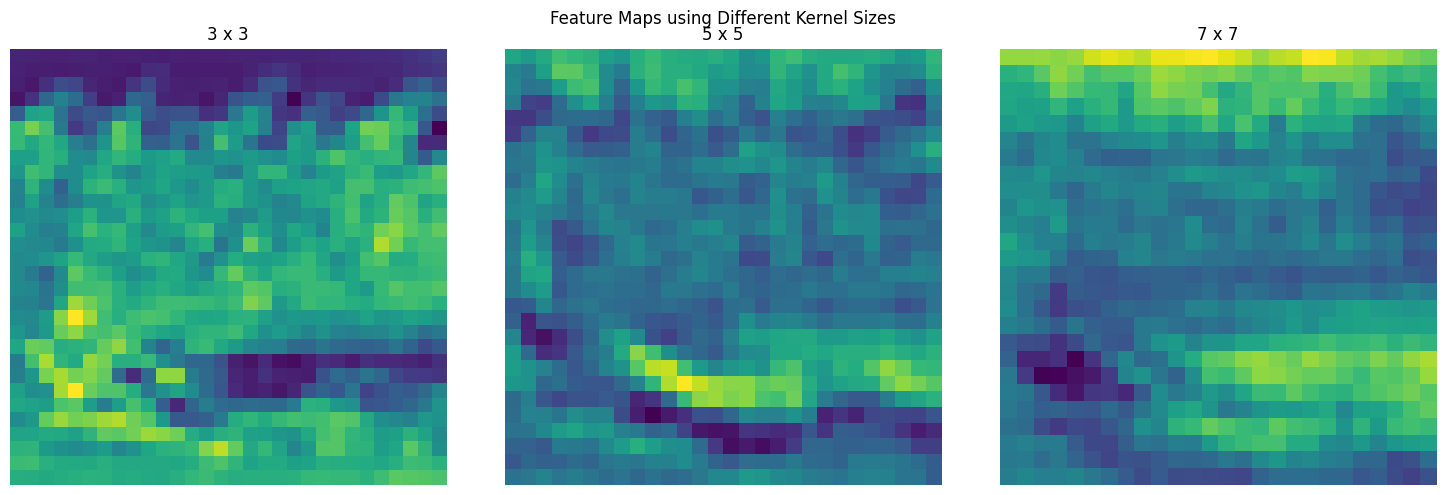

In [ ]:
# ============================================================
# TASK 2 - Compare Convolution Kernels (3x3, 5x5, 7x7)
# ============================================================

image, label = train_set[0]
image = image.unsqueeze(0)  # (1, 3, 32, 32)

kernels = [3, 5, 7]

plt.figure(figsize=(15, 5))
for i, k in enumerate(kernels):
    conv = nn.Conv2d(3, 1, kernel_size=k, stride=1, padding=0)
    feature_map = conv(image)

    print(f"Kernel Size : {k} x {k}")
    print("Feature Map Shape:", feature_map.shape)
    print()

    plt.subplot(1, 3, i + 1)
    plt.imshow(feature_map.squeeze().detach().numpy(), cmap="viridis")
    plt.title(f"{k} x {k}")
    plt.axis("off")

plt.suptitle("Feature Maps using Different Kernel Sizes")
plt.tight_layout()
plt.show()


Stride=1, Padding=0 (Valid)
Feature Map Shape: torch.Size([1, 1, 30, 30])

Stride=2, Padding=0 (Valid)
Feature Map Shape: torch.Size([1, 1, 15, 15])

Stride=1, Padding=1 (Same for 3x3)
Feature Map Shape: torch.Size([1, 1, 32, 32])



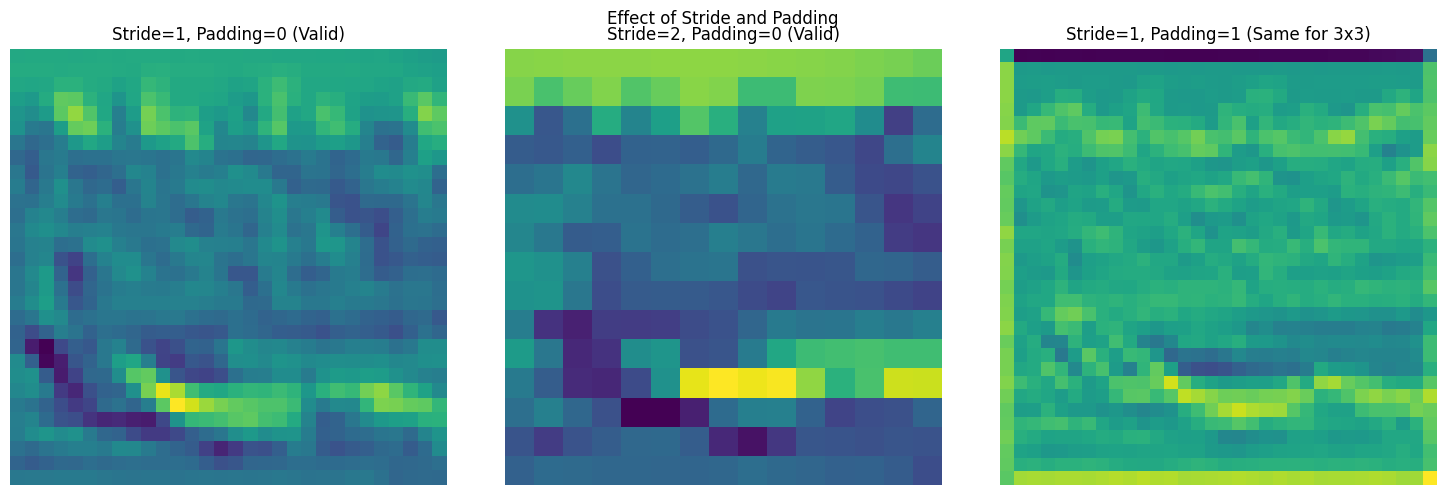

In [ ]:
# ============================================================
# TASK 3 - Compare Stride and Padding
# ============================================================

configs = [
    ("Stride=1, Padding=0 (Valid)", 1, 0),
    ("Stride=2, Padding=0 (Valid)", 2, 0),
    ("Stride=1, Padding=1 (Same for 3x3)", 1, 1)
]

plt.figure(figsize=(15, 5))

for i, (title, stride, padding) in enumerate(configs):
    conv = nn.Conv2d(3, 1, kernel_size=3, stride=stride, padding=padding)
    feature_map = conv(image)

    print(title)
    print("Feature Map Shape:", feature_map.shape)
    print()

    plt.subplot(1, 3, i + 1)
    plt.imshow(feature_map.squeeze().detach().numpy(), cmap="viridis")
    plt.title(title)
    plt.axis("off")

plt.suptitle("Effect of Stride and Padding")
plt.tight_layout()
plt.show()


Feature Map Shape: torch.Size([1, 8, 32, 32])


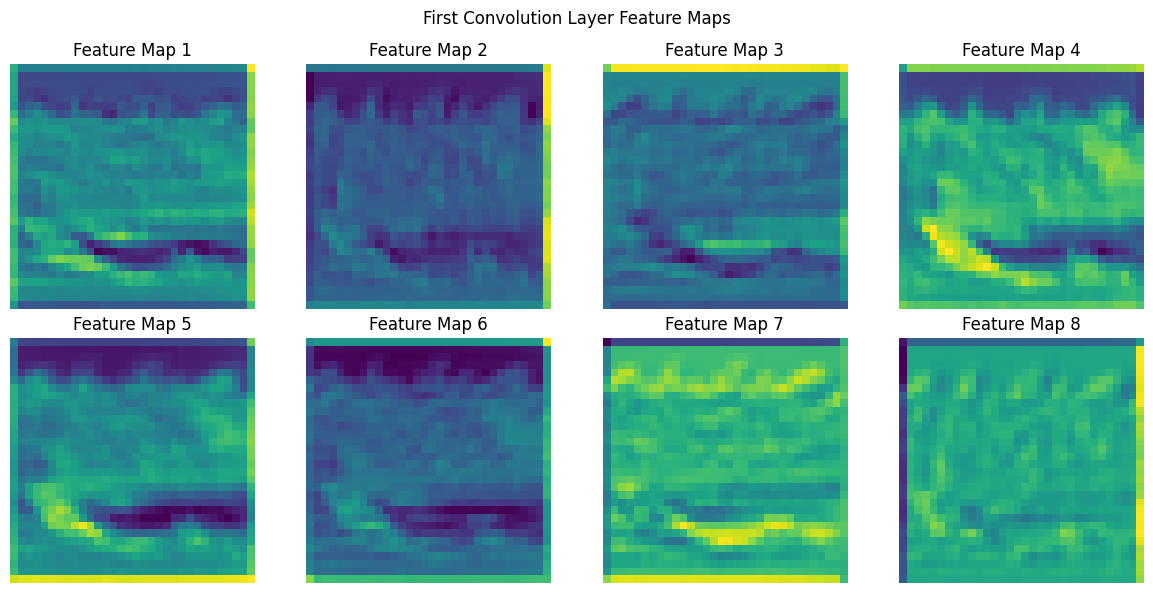

In [ ]:
# ============================================================
# TASK 4 - Visualize 8 Feature Maps
# ============================================================

conv1_demo = nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)
feature_maps = conv1_demo(image)

print("Feature Map Shape:", feature_maps.shape)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, i].detach().numpy(), cmap="viridis")
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")
plt.suptitle("First Convolution Layer Feature Maps")
plt.tight_layout()
plt.show()


Original Feature Map Shape : torch.Size([1, 1, 32, 32])
Max Pool Output Shape      : torch.Size([1, 1, 16, 16])
Average Pool Output Shape  : torch.Size([1, 1, 16, 16])


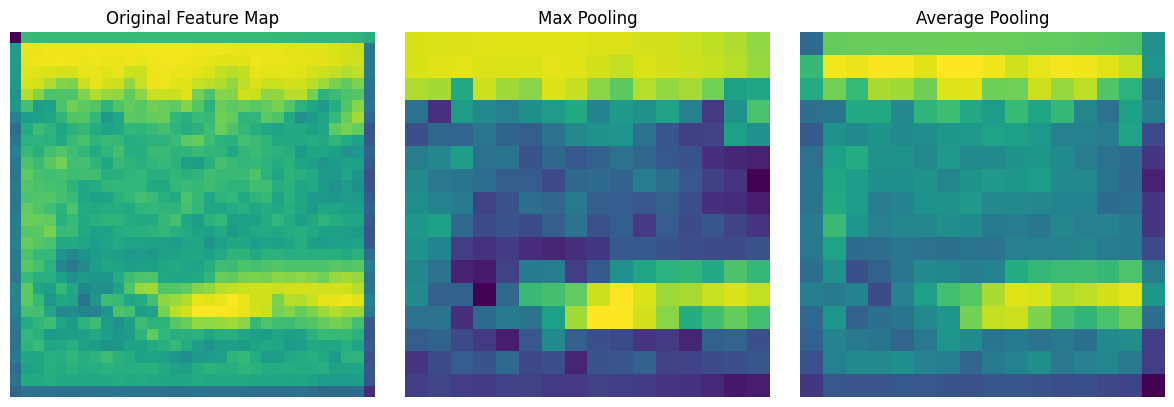

In [ ]:
# ============================================================
# TASK 5 - Max Pooling vs Average Pooling
# ============================================================

conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)
feature_map = conv(image)

max_pool = nn.MaxPool2d(2, 2)
avg_pool = nn.AvgPool2d(2, 2)

max_output = max_pool(feature_map)
avg_output = avg_pool(feature_map)

print("Original Feature Map Shape :", feature_map.shape)
print("Max Pool Output Shape      :", max_output.shape)
print("Average Pool Output Shape  :", avg_output.shape)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(feature_map[0, 0].detach().numpy(), cmap="viridis")
plt.title("Original Feature Map")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(max_output[0, 0].detach().numpy(), cmap="viridis")
plt.title("Max Pooling")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(avg_output[0, 0].detach().numpy(), cmap="viridis")
plt.title("Average Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()


Training Images : 40000
Validation Images: 10000
Testing Images  : 10000

CNN Architecture

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Epoch [ 1/20] | Train Loss: 1.4904 | Train Acc: 46.06% | Val Loss: 1.2688 | Val Acc: 55.18%
Epoch [ 2/20] | Train Loss: 1.1216 | Train Acc: 60.23% | Val Loss: 1.1005 | Val Acc: 60.73%
Epoch [ 3/20] | Train Loss: 0.9667 | Train Acc: 66.01% | Val Loss: 0.9995 | Val Acc: 64.37%
Epoch [ 4/20] | Train Loss: 0.8637 | Train Acc: 69.41% | Val Loss: 0.9443 | 

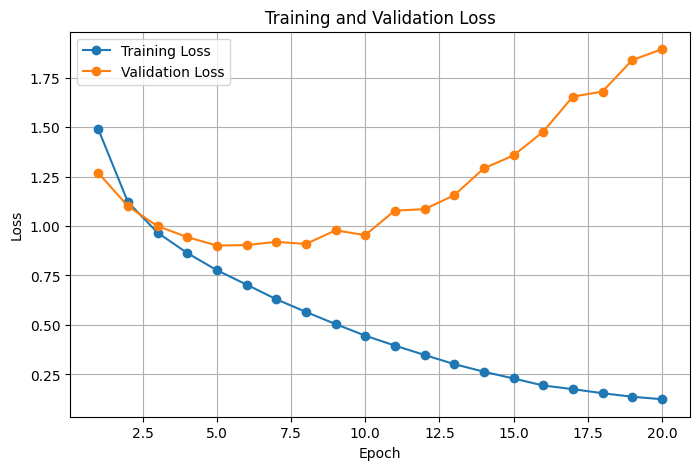

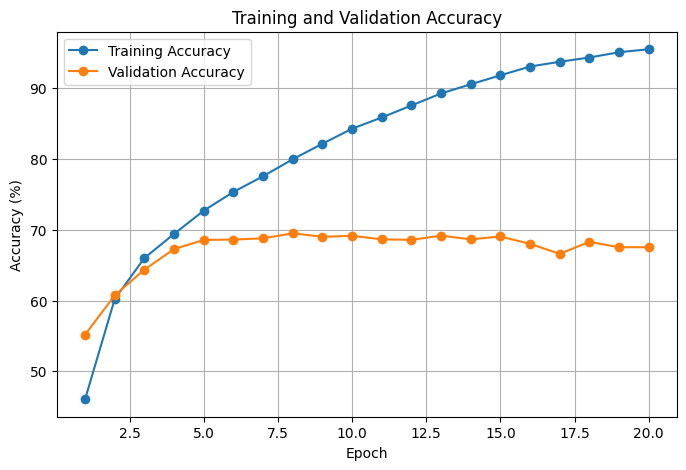

In [ ]:
# ============================================================
# TASK 6 - Build and Train CNN on CIFAR-10
# Required: Adam, 20 epochs, batch size 32
# ============================================================

batch_size = 32

# Create validation split from training data
train_size = int(0.8 * len(train_set))
val_size = len(train_set) - train_size
train_subset, val_subset = random_split(
    train_set,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

def make_loader(dataset, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=(DEVICE.type == "cuda")
    )

train_loader = make_loader(train_subset, shuffle=True)
val_loader = make_loader(val_subset, shuffle=False)
test_loader = make_loader(test_set, shuffle=False)

print("Training Images :", len(train_subset))
print("Validation Images:", len(val_subset))
print("Testing Images  :", len(test_set))

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        return self.fc2(x)  # logits; CrossEntropyLoss applies softmax internally

model = CNN().to(DEVICE)
print("\nCNN Architecture\n")
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 20
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []

for epoch in range(EPOCHS):
    # ---------------- TRAIN ----------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total

    # ---------------- VALIDATION ----------------
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100 * correct / total

    train_loss.append(epoch_train_loss)
    train_accuracy.append(epoch_train_acc)
    val_loss.append(epoch_val_loss)
    val_accuracy.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1:2d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.2f}%"
    )

# Training/validation plots
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_loss, marker="o", label="Training Loss")
plt.plot(range(1, EPOCHS + 1), val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_accuracy, marker="o", label="Training Accuracy")
plt.plot(range(1, EPOCHS + 1), val_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


MODEL PERFORMANCE
Accuracy  : 0.6741
Precision : 0.6764
Recall    : 0.6741
F1 Score  : 0.6736

Classification Report

              precision    recall  f1-score   support

    airplane       0.69      0.74      0.72      1000
  automobile       0.82      0.73      0.77      1000
        bird       0.61      0.51      0.55      1000
         cat       0.50      0.47      0.48      1000
        deer       0.56      0.69      0.62      1000
         dog       0.59      0.58      0.59      1000
        frog       0.76      0.72      0.74      1000
       horse       0.68      0.74      0.71      1000
        ship       0.81      0.77      0.79      1000
       truck       0.74      0.78      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.67     10000
weighted avg       0.68      0.67      0.67     10000



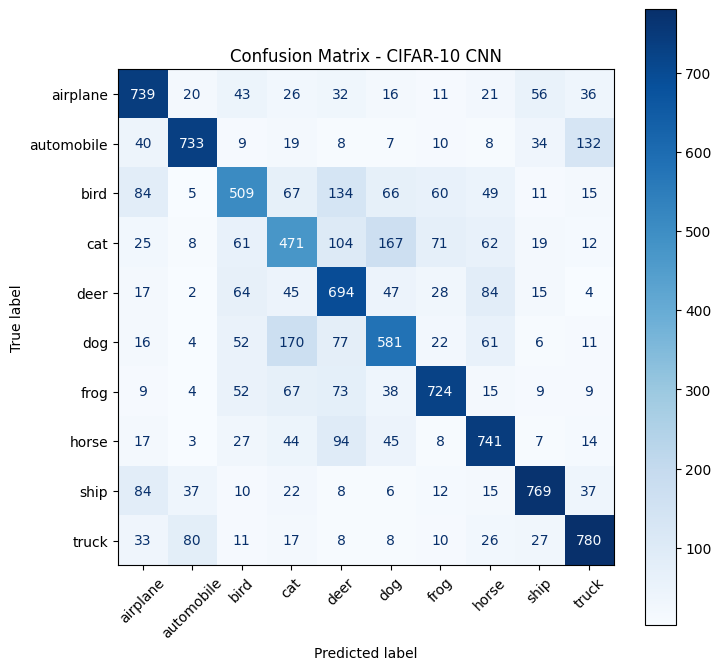

Total trainable parameters: 545098


In [ ]:
# ============================================================
# TASK 7 - Evaluate CNN Model
# Accuracy, Precision, Recall, F1, Confusion Matrix, Report
# ============================================================

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("==============================")
print("MODEL PERFORMANCE")
print("==============================")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - CIFAR-10 CNN")
plt.show()

# Total trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", trainable_params)


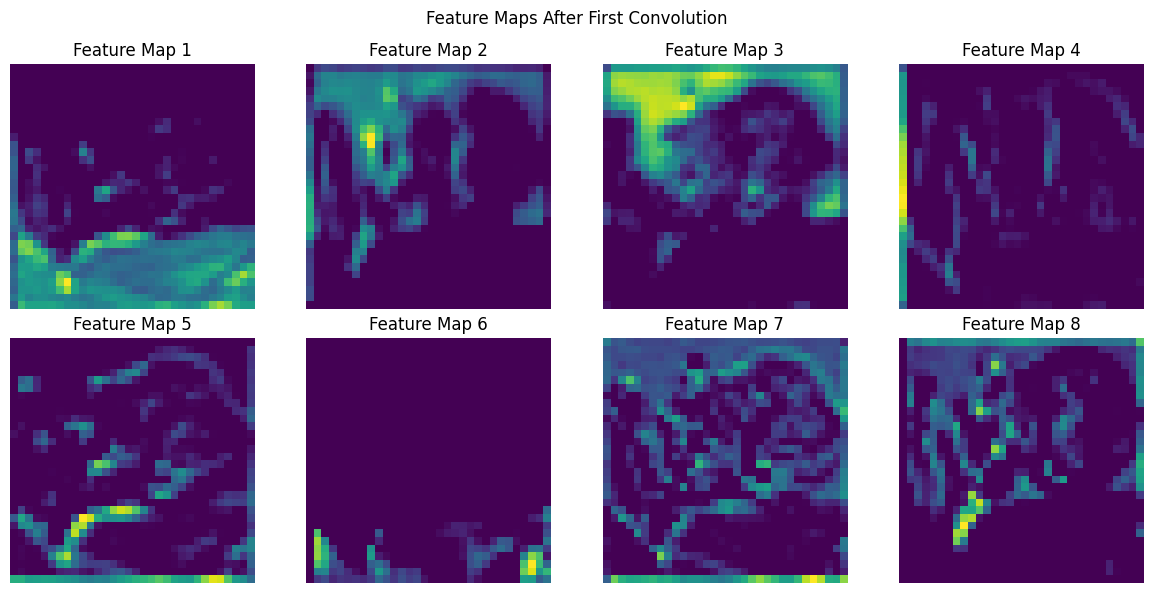

In [ ]:
# ============================================================
# FEATURE MAPS FROM THE TRAINED CNN (MANDATORY PLOT)
# ============================================================

model.eval()

sample_image, sample_label = test_set[0]
input_image = sample_image.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    first_feature_maps = model.relu1(model.conv1(input_image))

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(first_feature_maps[0, i].cpu().numpy(), cmap="viridis")
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")
plt.suptitle("Feature Maps After First Convolution")
plt.tight_layout()
plt.show()
